In [ ]:
%pip install plotly==5.23.0

In [1]:
import sklearn.metrics as metrics
from scorer.scorer import CobaldScorer
from common.parse_conllu import parse_conllu_incr
from more_itertools import zip_equal
import plotly.express as px

NO_SEM_PREDICTIONS_CONLLU = "t_no_sem.conllu"
SEM_PREDICTIONS_CONLLU = "t_with_sem.conllu"
GOLD_CONLLU = "t_gold.conllu"

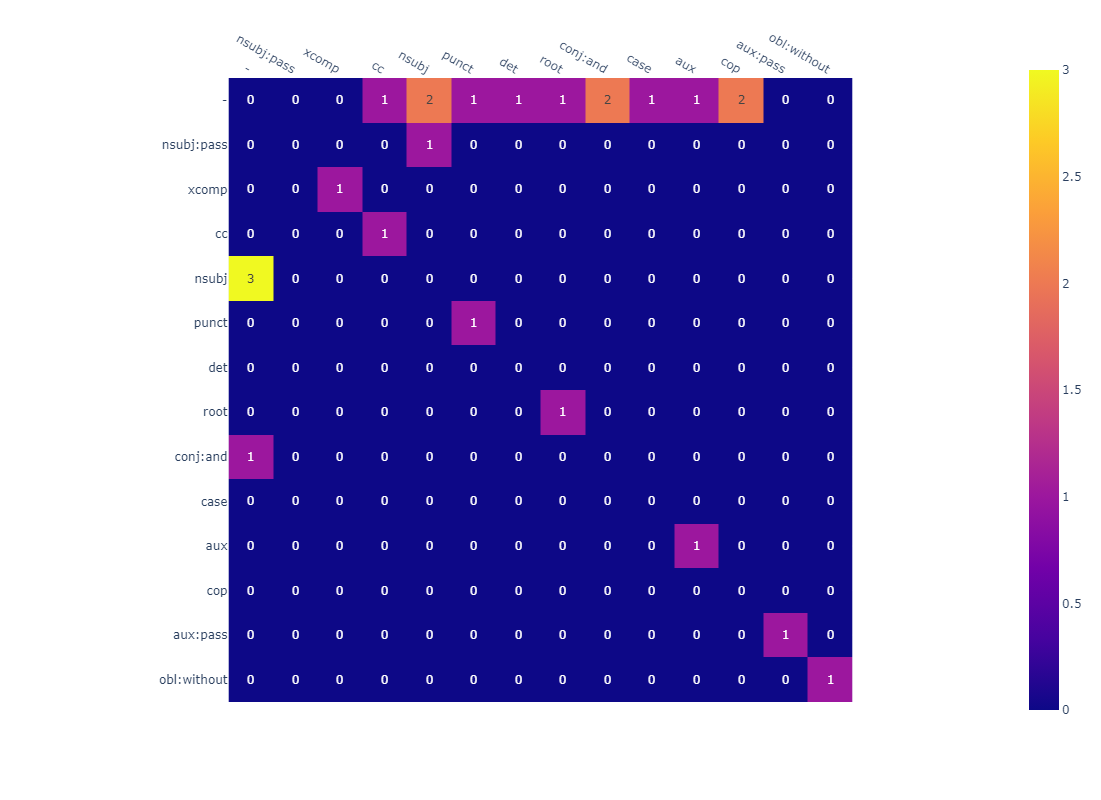

In [12]:
scorer = CobaldScorer()

deps_rels_no_sem = []
deps_rels_sem = []

def calc_deps_heads_agreement(test, gold):
    test_heads = set(test.deps.keys())
    gold_heads = set(gold.deps.keys())
    return len(test_heads & gold_heads)


def calc_deps_rels_agreement(test, gold):
    test_deps = set(test.deps.items())
    gold_deps = set(gold.deps.items())
    return len(test_deps & gold_deps)


with open(NO_SEM_PREDICTIONS_CONLLU, 'r') as no_sem_preds_file, open(SEM_PREDICTIONS_CONLLU, 'r') as sem_preds_file, open(GOLD_CONLLU, 'r') as gold_file:
    no_sem_sentences = parse_conllu_incr(no_sem_preds_file)
    sem_sentences = parse_conllu_incr(sem_preds_file)
    gold_sentences = parse_conllu_incr(gold_file)

    for no_sem_sentence, sem_sentence, gold_sentence in zip_equal(no_sem_sentences, sem_sentences, gold_sentences):
        # Align three sentences.
        _, gold_sentence_aligned1 = scorer._align_sentences(no_sem_sentence, gold_sentence)
        _, gold_sentence_aligned2 = scorer._align_sentences(sem_sentence, gold_sentence)
        _, gold_sentence_aligned = scorer._align_sentences(gold_sentence_aligned1, gold_sentence_aligned2)
        no_sem_sentence_aligned, gold_sentence_aligned = scorer._align_sentences(no_sem_sentence, gold_sentence_aligned)
        sem_sentence_aligned, gold_sentence_aligned = scorer._align_sentences(sem_sentence, gold_sentence_aligned)
        assert len(no_sem_sentence_aligned) == len(sem_sentence_aligned) == len(gold_sentence_aligned), \
            f"{no_sem_sentence_aligned.serialize()}\n{sem_sentence_aligned.serialize()}\n{gold_sentence_aligned.serialize()}"

        for no_sem_token, sem_token, gold_token in zip_equal(no_sem_sentence_aligned, sem_sentence_aligned, gold_sentence_aligned):
            is_mismatched = no_sem_token.is_empty() or sem_token.is_empty() or gold_token.is_empty()
            if is_mismatched:
                continue
            
            assert no_sem_token.form == sem_token.form == gold_token.form, \
                f"Error at sent_id={test_sentence.sent_id} : Tokens forms are mismatched."

            for head in (no_sem_token.deps.keys() | sem_token.deps.keys()):
                deps_rels_no_sem.append(no_sem_token.deps[head] if head in no_sem_token.deps else '-')
                deps_rels_sem.append(sem_token.deps[head] if head in sem_token.deps else '-')

deps_rels_tagset = ['-'] + list(set(deps_rels_no_sem) | set(deps_rels_sem) - set('-'))
cm = metrics.confusion_matrix(deps_rels_no_sem, deps_rels_sem, labels=deps_rels_tagset)

fig = px.imshow(cm, text_auto=True, x=deps_rels_tagset, y=deps_rels_tagset)
fig.update_layout(
    autosize=False,
    width=800,
    height=800,
)
fig.update_xaxes(side="top")
fig.show()